# Notebook 01 — CORD-19 Data Exploration & Tier Sampling

**Phase 1 · Task group 111.**
Goal: load the CORD-19 `metadata.csv`, understand what's in it, filter to COVID-relevant papers with usable abstracts, produce the Tier 1 / Tier 2 subset, and persist `papers_clean.parquet` + a tier manifest.

Design notes
* Tier-agnostic: the tier (`tier1` local 1k · `tier2` Kaggle 50k · `tier3` full) is read from `2_src/config.py`. Nothing else in the notebook changes between tiers.
* Cache-or-build: if `papers_clean.parquet` already exists for this tier, the notebook reuses it.
* All figures land in `4_results/<tier>/` and processed tables in `1_data/processed/<tier>/`.


In [1]:
import os, sys, json, warnings
from pathlib import Path

# --- make 2_src importable ------------------------------------------------
NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if (NB_DIR.parent / "2_src").exists() else NB_DIR
sys.path.insert(0, str(PROJECT_ROOT / "2_src"))

# --- tier selection -------------------------------------------------------
# Flip this to "tier2" on Kaggle. Nothing else in this notebook changes.
os.environ.setdefault("SCIRET_TIER", "tier1")

from config import get_config, SEED
CFG = get_config()
print(CFG.summary())

warnings.filterwarnings("ignore")


[SciRet:tier1] size=1000 root=/Users/kaysarulanasapurba/Desktop/ResumeProjects/SciRet/SciRetv2 chunks=chunks.parquet chroma=chroma_db/sciret_tier1_bge_m3_cs400_o50


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


## 1. Load raw metadata

CORD-19's `metadata.csv` is the canonical index over every paper in the corpus (title, abstract, publication info, full-text locations). We load it with `low_memory=False` because several columns (authors, mag_id, …) have mixed dtypes that otherwise trigger silent dtype warnings.

In [3]:
from data.loader import CORDDataLoader

loader = CORDDataLoader(root_dir=CFG.project_root)
meta = loader.load_metadata("metadata.csv")
print(f"Rows: {len(meta):,}  Columns: {len(meta.columns)}")
meta.head(3)


Rows: 1,056,660  Columns: 19


,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN


In [4]:
# Column types + missingness at a glance.
summary = pd.DataFrame({
    "dtype": meta.dtypes.astype(str),
    "n_missing": meta.isna().sum(),
    "pct_missing": (meta.isna().mean() * 100).round(1),
})
summary.sort_values("pct_missing", ascending=False).head(20)


,dtype,n_missing,pct_missing
mag_id,float64,1056660,100.0
arxiv_id,object,1042411,98.7
pmc_json_files,object,740918,70.1
pdf_json_files,object,682894,64.6
sha,object,682894,64.6
pmcid,object,667089,63.1
who_covidence_id,object,573725,54.3
pubmed_id,object,557728,52.8
doi,object,399880,37.8
url,object,369726,35.0


## 2. Publication year distribution

Paper date is stored in the `publish_time` column. We parse to a year integer and visualise the temporal spread — crucial context for a COVID-19 corpus because >95% of the on-topic material lands in 2019–2022.

In [5]:
meta["publish_time_parsed"] = pd.to_datetime(meta["publish_time"], errors="coerce")
meta["publish_year"] = meta["publish_time_parsed"].dt.year

year_counts = (
    meta["publish_year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .loc[lambda s: s.index >= 1990]
)
print(f"Parsed dates for {meta['publish_year'].notna().sum():,} / {len(meta):,} rows")
year_counts.tail(15)


Parsed dates for 518,871 / 1,056,660 rows


publish_year
2010      2223
2011      2337
2012      2471
2013      2948
2014      3207
2015      3461
2016      3944
2017      3691
2018      3982
2019      5630
2020    164751
2021    219516
2022     85310
2023         1
2024         1
Name: count, dtype: int64

saved -> /Users/kaysarulanasapurba/Desktop/ResumeProjects/SciRet/SciRetv2/1_data/processed/tier1/dataset_overview.png


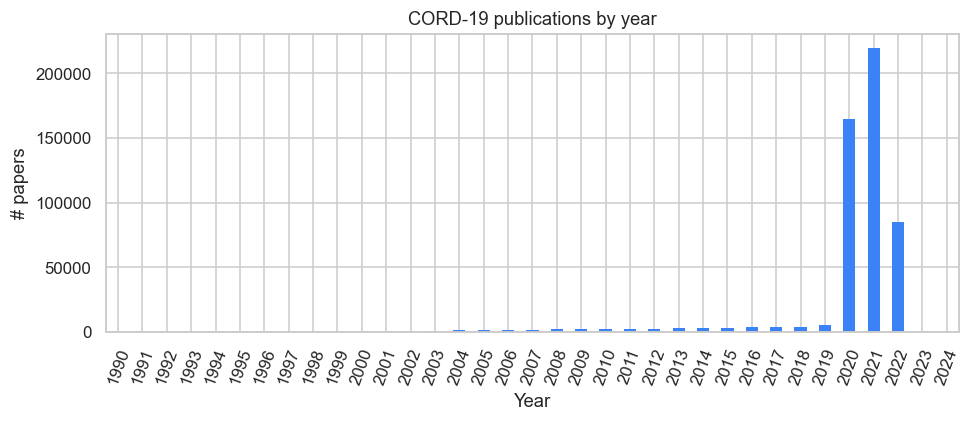

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
year_counts.plot(kind="bar", ax=ax, color="#3b82f6", edgecolor="none")
ax.set_title("CORD-19 publications by year")
ax.set_xlabel("Year")
ax.set_ylabel("# papers")
ax.tick_params(axis="x", rotation=70)
fig.tight_layout()

out_png = CFG.processed_dir / "dataset_overview.png"
fig.savefig(out_png, dpi=150)
print(f"saved -> {out_png}")
plt.show()


## 3. COVID-relevance filter

CORD-19 also contains older coronavirus/SARS/MERS literature. For SciRet v2 we want papers that are *COVID-specific*, which we approximate with a keyword match on title + abstract. The rule below is the same one used for Tier 2; only the sample size downstream changes.

In [7]:
COVID_PATTERN = (
    r"\b(covid[- ]?19|covid|sars[- ]?cov[- ]?2|2019[- ]?ncov|"
    r"novel coronavirus|pandemic coronavirus)\b"
)

title_txt = meta["title"].fillna("").str.lower()
abs_txt = meta["abstract"].fillna("").str.lower()
mask_covid = title_txt.str.contains(COVID_PATTERN, regex=True) | abs_txt.str.contains(COVID_PATTERN, regex=True)
mask_abs = meta["abstract"].fillna("").str.len() > 100

meta_f = meta[mask_covid & mask_abs].copy()
print(f"After COVID-keyword + abstract>=100 chars filter: {len(meta_f):,} rows")


After COVID-keyword + abstract>=100 chars filter: 528,190 rows


In [8]:
# Dedupe on cord_uid then on exact-title collisions.
before = len(meta_f)
meta_f = meta_f.drop_duplicates(subset="cord_uid")
meta_f = meta_f.drop_duplicates(subset="title")
print(f"Deduped: {before:,} -> {len(meta_f):,}")


Deduped: 528,190 -> 397,168


## 4. Tier sample

`get_config().tier_size` is 1 000 for Tier 1, 50 000 for Tier 2, `-1` for Tier 3 (keep everything). We stratify the sample by publication year so each tier has the same temporal mix; this matters because CORD-19 is front-loaded on 2020–2021.

In [9]:
def stratified_sample(df, n, seed=SEED):
    if n < 0 or n >= len(df):
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    year_col = df["publish_year"].fillna(-1).astype(int)
    groups = df.groupby(year_col, group_keys=False)
    # proportional allocation with floor(1) per bucket that has rows
    sizes = (groups.size() / len(df) * n).round().astype(int).clip(lower=1)
    # normalise to exactly n
    while sizes.sum() > n:
        sizes[sizes.idxmax()] -= 1
    while sizes.sum() < n:
        sizes[sizes.idxmax()] += 1
    parts = [
        g.sample(n=min(sizes[y], len(g)), random_state=seed)
        for y, g in groups
    ]
    return pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)

subset = stratified_sample(meta_f, CFG.tier_size, seed=SEED)
print(f"Tier '{CFG.tier}' sample: {len(subset):,} papers")
subset["publish_year"].value_counts().sort_index().tail(10)


Tier 'tier1' sample: 1,000 papers


publish_year
2013.0      1
2014.0      1
2015.0      1
2016.0      1
2017.0      1
2018.0      1
2019.0      1
2020.0    104
2021.0    193
2022.0     85
Name: count, dtype: int64

## 5. Persist subset + manifest

We only keep the columns downstream notebooks actually use, save to `papers_clean.parquet`, and write a `tier_manifest.json` so Notebook 02+ can confirm they're reading the right tier.

In [10]:
KEEP_COLS = [
    "cord_uid", "title", "abstract", "authors", "journal",
    "publish_time", "publish_year", "doi", "pmcid", "pdf_json_files",
]
subset_out = subset[[c for c in KEEP_COLS if c in subset.columns]].copy()
subset_out["abstract"] = subset_out["abstract"].fillna("").str.strip()
subset_out["title"] = subset_out["title"].fillna("").str.strip()

out_parquet = CFG.papers_clean_path
subset_out.to_parquet(out_parquet, index=False)
print(f"saved -> {out_parquet}  ({out_parquet.stat().st_size/1024:.1f} KB)")

manifest = {
    "tier": CFG.tier,
    "target_size": CFG.tier_size,
    "actual_size": int(len(subset_out)),
    "seed": SEED,
    "filter": "covid keyword in title|abstract AND abstract>=100 chars",
    "columns": list(subset_out.columns),
    "source": str(loader.raw_dir / "metadata.csv"),
    "output": str(out_parquet),
}
CFG.tier_manifest_path.write_text(json.dumps(manifest, indent=2))
print(f"manifest -> {CFG.tier_manifest_path}")


saved -> /Users/kaysarulanasapurba/Desktop/ResumeProjects/SciRet/SciRetv2/1_data/processed/tier1/papers_clean.parquet  (1017.2 KB)
manifest -> /Users/kaysarulanasapurba/Desktop/ResumeProjects/SciRet/SciRetv2/1_data/processed/tier1/tier_manifest.json


## 6. Sanity checks

A quick look at sample titles and abstract length distribution. If something here is off (e.g., abstracts empty, titles truncated, wrong years) it's far cheaper to catch it now than after running 2h of embeddings in Notebook 03.

In [11]:
subset_out.sample(5, random_state=SEED)[["title", "publish_year", "abstract"]].assign(
    abstract_preview=lambda d: d["abstract"].str.slice(0, 160) + "…"
).drop(columns="abstract")


,title,publish_year,abstract_preview
521,Analysis of Gender-Dependent Personal Protecti...,2020.0,During the coronavirus-19 disease (COVID-19) p...
737,Quality adjusted life years in the time of COV...,NaN,The quality adjusted life year (QALY) as a bas...
740,Acute Pancreatitis in a Teenager With SARS-CoV...,2021.0,The clinical manifestations of SARS-CoV-2 infe...
660,Make good use of big data: A home for everyone,NaN,The ongoing COVID-19 pandemic should teach us ...
411,An iterative topic model filtering framework f...,2022.0,Conspiracy theories have seen a rise in popula...


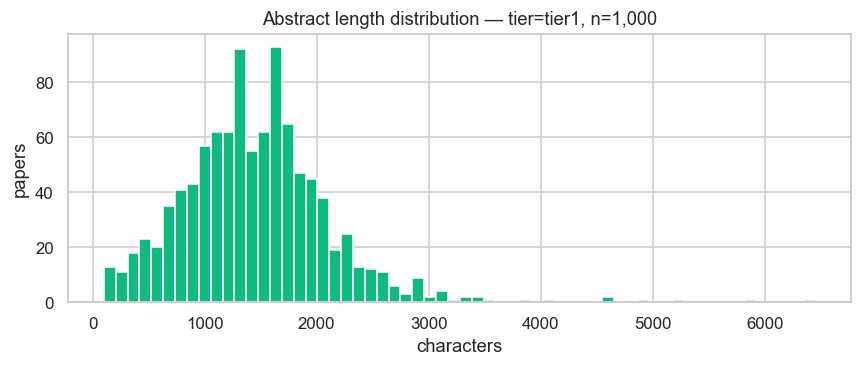

median chars: 1412  | p95 chars: 2523


In [12]:
abs_len = subset_out["abstract"].str.len()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(abs_len, bins=60, color="#10b981", edgecolor="white")
ax.set_title(f"Abstract length distribution — tier={CFG.tier}, n={len(subset_out):,}")
ax.set_xlabel("characters")
ax.set_ylabel("papers")
fig.tight_layout()
fig.savefig(CFG.processed_dir / "abstract_length_hist.png", dpi=140)
plt.show()

print("median chars:", int(abs_len.median()),
      " | p95 chars:", int(abs_len.quantile(0.95)))


---
**Outputs produced by this notebook**

| path | purpose |
|------|---------|
| `1_data/processed/<tier>/papers_clean.parquet` | clean Tier sample, feeds Notebook 02 |
| `1_data/processed/<tier>/tier_manifest.json`   | tier metadata so later notebooks can assert |
| `1_data/processed/<tier>/dataset_overview.png` | publication year bar chart |
| `1_data/processed/<tier>/abstract_length_hist.png` | abstract length histogram |

**Next:** Notebook 02 — text chunking strategies over `papers_clean.parquet`.
